In [243]:
%matplotlib inline

In [244]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

    


In [201]:
df = pd.read_csv("C:/Users/user/Downloads/3 lesson_3_data_1_.csv", encoding='cp1251')

In [202]:
df

,Unnamed: 0,tk,pl,dia,hs,tc,cta,id_art,id_subsubfam,id_subfam,...,id_famn,id_seccion,id_subagr,id_agr,vta,uni,id_artn,art_sp,fam_sp,fam_en
0,1242,120071109002055793,1,2007/11/09,0.505729,110000761,11000076,21895,101070640100,1010706401,...,10107064,10107,101,1,0.68,1.0,21895,MARAVILLA 500 G Store_Brand,PASTA ALIMENTICIA SE,pasta
1,1243,120070601004053633,1,2007/06/01,0.588519,110000761,11000076,21816,101070640100,1010706401,...,10107064,10107,101,1,0.38,1.0,21816,FIDEO CABELLIN 500 G Store_Brand,PASTA ALIMENTICIA SE,pasta
2,1244,120070928004076410,1,2007/09/28,0.785498,28491841,2849184,562840,101070640100,1010706401,...,10107064,10107,101,1,1.55,2.0,562840,SPAGUETTI Nє 5 500 G Brand_1,PASTA ALIMENTICIA SE,pasta
3,1245,120070616003074261,1,2007/06/16,0.550961,95931501,9593150,28914,101070640100,1010706401,...,10107064,10107,101,1,1.03,2.0,28914,FIDEO FIDEUБ 500 Brand_7,PASTA ALIMENTICIA SE,pasta
4,1246,120070519001018477,1,2007/05/19,0.804954,93265591,9326559,159867,101070640100,1010706401,...,10107064,10107,101,1,1.09,1.0,159867,MACARRONES GRATINAR 5 Brand_2,PASTA ALIMENTICIA SE,pasta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48124,5142333,660820070702005033693,6608,2007/07/02,0.575660,45518841,4551884,22115,101070640100,1010706401,...,10107064,10107,101,1,0.71,1.0,22115,FIDEOS 0 500 G Brand_4,PASTA ALIMENTICIA SE,pasta
48125,5142335,660820070618006015969,6608,2007/06/18,0.829954,110824211,11082421,22124,101070640100,1010706401,...,10107064,10107,101,1,0.71,1.0,22124,PLUMAS 3 500 G Brand_4,PASTA ALIMENTICIA SE,pasta
48126,5150526,670120071110001433949,6701,2007/11/10,0.384120,1408670389,999860498,21818,101070640100,1010706401,...,10107064,10107,101,1,0.48,1.0,21818,MACARRONES 500 G Store_Brand,PASTA ALIMENTICIA SE,pasta
48127,5150527,670120071110001433949,6701,2007/11/10,0.384120,1408670389,999860498,21814,101070640100,1010706401,...,10107064,10107,101,1,0.48,1.0,21814,SPAGHETTI 500 G Store_Brand,PASTA ALIMENTICIA SE,pasta


In [203]:
user_df = df[['tc', 'art_sp']]

In [204]:
user_df.head()

,tc,art_sp
0,110000761,MARAVILLA 500 G Store_Brand
1,110000761,FIDEO CABELLIN 500 G Store_Brand
2,28491841,SPAGUETTI Nє 5 500 G Brand_1
3,95931501,FIDEO FIDEUБ 500 Brand_7
4,93265591,MACARRONES GRATINAR 5 Brand_2


In [205]:
user_df = user_df.rename(columns = {'tc': 'user_id', 'art_sp': 'brand_info'})

In [206]:
user_df.head()

,user_id,brand_info
0,110000761,MARAVILLA 500 G Store_Brand
1,110000761,FIDEO CABELLIN 500 G Store_Brand
2,28491841,SPAGUETTI Nє 5 500 G Brand_1
3,95931501,FIDEO FIDEUБ 500 Brand_7
4,93265591,MACARRONES GRATINAR 5 Brand_2


In [207]:
def split_brand_info(brand_name_data):
    return brand_name_data.split(' ')[-1]

In [208]:
user_df['brand_name'] = user_df.brand_info.apply(split_brand_info)

In [209]:
user_df

,user_id,brand_info,brand_name
0,110000761,MARAVILLA 500 G Store_Brand,Store_Brand
1,110000761,FIDEO CABELLIN 500 G Store_Brand,Store_Brand
2,28491841,SPAGUETTI Nє 5 500 G Brand_1,Brand_1
3,95931501,FIDEO FIDEUБ 500 Brand_7,Brand_7
4,93265591,MACARRONES GRATINAR 5 Brand_2,Brand_2
...,...,...,...
48124,45518841,FIDEOS 0 500 G Brand_4,Brand_4
48125,110824211,PLUMAS 3 500 G Brand_4,Brand_4
48126,1408670389,MACARRONES 500 G Store_Brand,Store_Brand
48127,1408670389,SPAGHETTI 500 G Store_Brand,Store_Brand


In [210]:
user_purchases = user_df.groupby('user_id', as_index = False) \
                        .agg({'brand_name': 'count'}) \
                        .rename(columns = {'brand_name': 'purchase'}) \
                        .query('purchase >= 5')

In [211]:
user_unique_brands = user_df.groupby('user_id', as_index=False) \
        .agg({'brand_name': pd.Series.nunique}) \
        .rename(columns = {'brand_name': 'unique_brands'})

In [212]:
loyalty_brand_purchases = user_df.groupby(['user_id', 'brand_name'], as_index = False) \
        .agg({'brand_info': 'count'}) \
        .sort_values(['user_id', 'brand_info'], ascending=[False, False]) \
        .groupby('user_id') \
        .head(1) \
        .rename(columns = {'brand_name': 'lovely_brand', 'brand_info': 'lovely_brand_purchases'})

In [213]:
loyalty_df = user_purchases \
        .merge(user_unique_brands, on='user_id') \
        .merge(lovely_brand_purchases, on='user_id')

In [214]:
loyalty_df.head()

,user_id,purchase,unique_brands,lovely_brand,lovely_brand_purchases
0,1031,6,2,Store_Brand,5
1,4241,5,2,Brand_4,3
2,25971,7,2,Store_Brand,5
3,40911,27,5,Brand_4,19
4,45181,5,4,Store_Brand,2


In [215]:
loyalty_users = loyalty_df[loyalty_df.unique_brands == 1]

In [216]:
#метрики

In [217]:
loyalty_df['loyalty_score'] = loyalty_df.lovely_brand_purchases / loyalty_df.purchase

In [218]:
loyalty_df.head()

,user_id,purchase,unique_brands,lovely_brand,lovely_brand_purchases,loyalty_score
0,1031,6,2,Store_Brand,5,0.833333
1,4241,5,2,Brand_4,3,0.600000
2,25971,7,2,Store_Brand,5,0.714286
3,40911,27,5,Brand_4,19,0.703704
4,45181,5,4,Store_Brand,2,0.400000


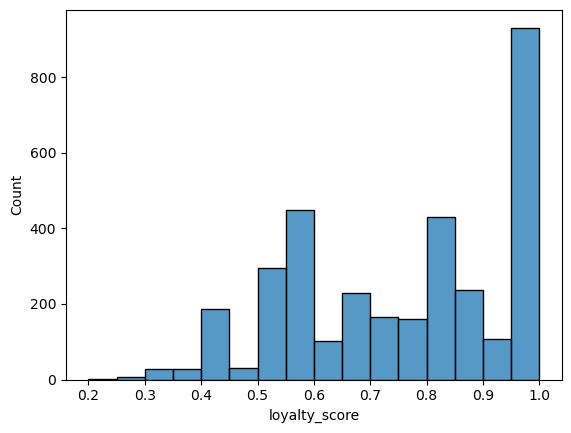

In [231]:
ax = sns.histplot(loyalty_df.loyalty_score, kde=False)
plt.show()

In [252]:
# Group and aggregate the data
brand_stats = loyalty_df.groupby('lovely_brand', as_index=False) \
                      .agg({'loyalty_score': 'median',
                           'user_id': 'count'})
plt.show()



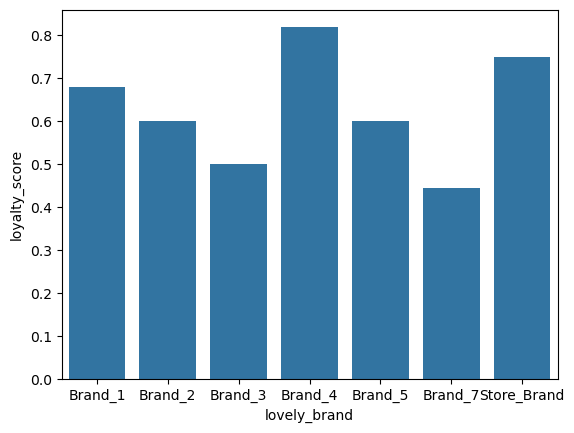

In [262]:
ax = sns.barplot(x="lovely_brand", y="loyalty_score", data=brand_stats)
plt.show()